In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F 
from torch import optim
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pyvirtualdisplay import Display
from IPython import display as ipythondisplay
from IPython.display import clear_output
from pathlib import Path

import random, os.path, math, glob, csv, base64, itertools, sys
import gym
from gym.wrappers.record_video import RecordVideo
from pprint import pprint

# The following code is will be used to visualize the environments.

def show_video(directory):
    html = []
    for mp4 in Path(directory).glob("*.mp4"):
        video_b64 = base64.b64encode(mp4.read_bytes())
        html.append('''<video alt="{}" autoplay 
                      loop controls style="height: 400px;">
                      <source src="data:video/mp4;base64,{}" type="video/mp4" />
                 </video>'''.format(mp4, video_b64.decode('ascii')))
    ipythondisplay.display(ipythondisplay.HTML(data="<br>".join(html)))
    
display = Display(visible=0, size=(1400, 900))
display.start()

def make_seed(seed):
    np.random.seed(seed=seed)
    torch.manual_seed(seed=seed)

In [2]:
import torch
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, dim_observation, n_actions):
        super(Model, self).__init__()

        self.n_actions = n_actions
        self.dim_observation = dim_observation

        self.net = nn.Sequential(
            nn.Linear(self.dim_observation, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, self.n_actions),
            nn.Softmax(dim=-1)
        )

        self.saved_log_probs = []
        self.rewards = []

    def forward(self, state):
        return self.net(state)

    def select_action(self, state):
        if not isinstance(state, torch.Tensor):
            state = torch.tensor(state, dtype=torch.float32)

        probs = self.forward(state)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()

        self.saved_log_probs.append(dist.log_prob(action))

        return action.item()

In [3]:
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import gym

from gym.wrappers import RecordVideo


class BaseAgent:
    
    def __init__(self, config):
        self.config = config
        self.env = gym.make(config['env_id'])
        make_seed(config['seed'])

        try:
            self.env.reset(seed=config['seed'])
        except:
            self.env.seed(config['seed'])

        self.model = Model(
            self.env.observation_space.shape[0],
            self.env.action_space.n
        )

        self.gamma = config['gamma']
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=config['learning_rate']
        )

        self.monitor_env = RecordVideo(
            gym.make(config['env_id']),   
            './video',
            episode_trigger=lambda episode_number: True
        )
    
    def _make_returns(self, rewards):
        returns = np.zeros(len(rewards), dtype=np.float32)
        returns[-1] = rewards[-1]
        for t in reversed(range(len(rewards) - 1)):
            returns[t] = rewards[t] + self.gamma * returns[t + 1]
        return returns
    
    def optimize_model(self, n_trajectories):
        trajectory_rewards = []
        policy_losses = []

        for _ in range(n_trajectories):
            out = self.env.reset()
            if isinstance(out, tuple):
                observation, _ = out
            else:
                observation = out

            done = False
            rewards = []
            log_probs = []

            while not done:
                observation = torch.tensor(observation, dtype=torch.float32)

                probs = self.model(observation)
                dist = torch.distributions.Categorical(probs)
                action = dist.sample()
                log_prob = dist.log_prob(action)

                step_out = self.env.step(action.item())

                if len(step_out) == 5:
                    next_observation, reward, terminated, truncated, info = step_out
                    done = terminated or truncated
                else:
                    next_observation, reward, done, info = step_out

                rewards.append(reward)
                log_probs.append(log_prob)
                observation = next_observation

            returns = self._make_returns(rewards)
            returns = torch.tensor(returns, dtype=torch.float32)

            if len(returns) > 1:
                returns = (returns - returns.mean()) / (returns.std() + 1e-8)

            for log_prob, G in zip(log_probs, returns):
                policy_losses.append(-log_prob * G)

            trajectory_rewards.append(np.sum(rewards))

        policy_loss = torch.stack(policy_losses).sum()

        self.optimizer.zero_grad()
        policy_loss.backward()
        self.optimizer.step()

        return np.array(trajectory_rewards)
    
    def train(self, n_trajectories, n_update):
        rewards = []
        for episode in range(n_update):
            rewards.append(self.optimize_model(n_trajectories))
            print(
                f'Episode {episode + 1}/{n_update}: '
                f'rewards {round(rewards[-1].mean(), 2)} +/- {round(rewards[-1].std(), 2)}'
            )
        
        r = pd.DataFrame(
            itertools.chain(*(itertools.product([i], rewards[i]) for i in range(len(rewards)))),
            columns=['Epoch', 'Reward']
        )
        sns.lineplot(x="Epoch", y="Reward", data=r, ci='sd')
        
    def evaluate(self):
        out = self.monitor_env.reset()
        if isinstance(out, tuple):
            observation, _ = out
        else:
            observation = out

        reward_episode = 0
        done = False
            
        while not done:
            observation = torch.tensor(observation, dtype=torch.float32)

            with torch.no_grad():
                probs = self.model(observation)
                action = torch.argmax(probs).item()

            step_out = self.monitor_env.step(action)

            if len(step_out) == 5:
                observation, reward, terminated, truncated, info = step_out
                done = terminated or truncated
            else:
                observation, reward, done, info = step_out

            reward_episode += reward

        print(f'Reward: {reward_episode}')
        self.monitor_env.close()

In [4]:
class ActorNetwork(nn.Module):

    def __init__(self, input_size, hidden_size, action_size):
        super(ActorNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_size)

    def forward(self, x):
        out = F.relu(self.fc1(x))
        out = F.relu(self.fc2(out))
        out = F.softmax(self.fc3(out), dim=-1)
        return out
    
    def select_action(self, x):
        return torch.multinomial(self(x), 1).detach().numpy()

In [5]:
class ValueNetwork(nn.Module):

    def __init__(self, input_size, hidden_size, output_size):
        super(ValueNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = F.relu(self.fc1(x))
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out

In [6]:
class A2CAgent:

    def __init__(self, config):
        self.config = config
        self.env = gym.make(config['env_id'])
        make_seed(config['seed'])

        try:
            self.env.reset(seed=config['seed'])
        except:
            self.env.seed(config['seed'])

        self.gamma = config['gamma']

        # video env тусдаа байх нь зөв
        self.monitor_env = gym.make(config['env_id'])

        self.value_network = ValueNetwork(self.env.observation_space.shape[0], 16, 1)
        self.actor_network = ActorNetwork(self.env.observation_space.shape[0], 16, self.env.action_space.n)

        self.value_network_optimizer = optim.RMSprop(
            self.value_network.parameters(),
            lr=config['value_network']['learning_rate']
        )
        self.actor_network_optimizer = optim.RMSprop(
            self.actor_network.parameters(),
            lr=config['actor_network']['learning_rate']
        )

    # def _returns_advantages(self, rewards, dones, values, next_value):
    #     returns = np.append(np.zeros_like(rewards), [next_value], axis=0)

    #     for t in reversed(range(rewards.shape[0])):
    #         returns[t] = rewards[t] + self.gamma * returns[t + 1] * (1 - dones[t])

    #     returns = returns[:-1]
    #     advantages = returns - values
    #     return returns, advantages

    def returns_advantages(rewards, dones, values, next_values, gamma):
        # rewards, dones, values: [T, N]
        # next_values: [N]
        T, N = rewards.shape
        returns = np.zeros((T, N), dtype=np.float32)

        future = next_values.copy()
        for t in reversed(range(T)):
            future = rewards[t] + gamma * future * (1 - dones[t])
            returns[t] = future

        advantages = returns - values
        return returns, advantages

    def training_batch(self, epochs, batch_size):
        episode_count = 0
        actions = np.empty((batch_size,), dtype=np.int64)
        dones = np.empty((batch_size,), dtype=np.bool_)
        rewards = np.empty((batch_size,), dtype=np.float32)
        values = np.empty((batch_size,), dtype=np.float32)
        observations = np.empty((batch_size,) + self.env.observation_space.shape, dtype=np.float32)

        out = self.env.reset()
        observation = out[0] if isinstance(out, tuple) else out

        rewards_test = []

        for epoch in range(epochs):
            for i in range(batch_size):
                observations[i] = observation

                obs_t = torch.tensor(observation, dtype=torch.float32)
                values[i] = self.value_network(obs_t).detach().item()

                policy = self.actor_network(obs_t)
                action = torch.multinomial(policy, 1).item()
                actions[i] = action

                step_out = self.env.step(action)
                if len(step_out) == 5:
                    observation, rewards[i], terminated, truncated, _ = step_out
                    dones[i] = terminated or truncated
                else:
                    observation, rewards[i], dones[i], _ = step_out

                if dones[i]:
                    out = self.env.reset()
                    observation = out[0] if isinstance(out, tuple) else out

            if dones[-1]:
                next_value = 0.0
            else:
                next_value = self.value_network(
                    torch.tensor(observation, dtype=torch.float32)
                ).detach().item()

            episode_count += dones.sum()

            returns, advantages = self._returns_advantages(rewards, dones, values, next_value)
            self.optimize_model(observations, actions, returns, advantages)

            if epoch % 50 == 0 or epoch == epochs - 1:
                rewards_test.append(np.array([self.evaluate() for _ in range(20)]))
                print(
                    f"Epoch {epoch}/{epochs}: Mean rewards: "
                    f"{round(rewards_test[-1].mean(), 2)}, Std: {round(rewards_test[-1].std(), 2)}"
                )

                if rewards_test[-1].mean() > 490 and epoch != epochs - 1:
                    print("Early stopping!")
                    break

                out = self.env.reset()
                observation = out[0] if isinstance(out, tuple) else out

    def optimize_model(self, observations, actions, returns, advantages):
        observations = torch.tensor(observations, dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.int64)
        returns = torch.tensor(returns[:, None], dtype=torch.float32)
        advantages = torch.tensor(advantages, dtype=torch.float32)

        # Critic
        values = self.value_network(observations)              # [B, 1]
        value_loss = F.mse_loss(values, returns)

        self.value_network_optimizer.zero_grad()
        value_loss.backward()
        self.value_network_optimizer.step()

        # Actor
        policy = self.actor_network(observations)             # [B, A]
        dist = torch.distributions.Categorical(policy)
        log_probs = dist.log_prob(actions)                    # [B]
        entropy = dist.entropy().mean()

        actor_loss = -(log_probs * advantages.detach()).mean() - 0.001 * entropy

        self.actor_network_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_network_optimizer.step()

    def evaluate(self, render=False):
        env = self.monitor_env if render else self.env

        out = env.reset()
        observation = out[0] if isinstance(out, tuple) else out

        reward_episode = 0
        done = False

        while not done:
            observation = torch.tensor(observation, dtype=torch.float32)

            with torch.no_grad():
                policy = self.actor_network(observation)
                action = torch.argmax(policy).item()

            step_out = env.step(action)
            if len(step_out) == 5:
                observation, reward, terminated, truncated, info = step_out
                done = terminated or truncated
            else:
                observation, reward, done, info = step_out

            reward_episode += reward

        return reward_episode

In [7]:
import os
import gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


class SharedActorNetwork(nn.Module):
    def __init__(self, obs_dim, hidden_size, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.net(x)


class SharedValueNetwork(nn.Module):
    def __init__(self, obs_dim, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.net(x)

In [8]:
import os
import shutil
import imageio.v2 as imageio
import cv2
from pathlib import Path
from gym.wrappers import RecordVideo


class SharedA2CAgent:
    def __init__(self, config):
        self.config = config
        self.env = gym.make(config['env_id'])
        self.gamma = config['gamma']
        self.entropy_coef = config['entropy']

        np.random.seed(config['seed'])
        torch.manual_seed(config['seed'])

        try:
            self.env.reset(seed=config['seed'])
        except:
            try:
                self.env.seed(config['seed'])
            except:
                pass

        out = self.env.reset()
        if isinstance(out, tuple):
            obs_n, _ = out
        else:
            obs_n = out

        obs_n = np.array(obs_n, dtype=np.float32)

        self.n_agents = obs_n.shape[0]
        self.obs_dim = obs_n.shape[1]
        self.action_dim = self.env.action_space[0].n

        self.actor_network = SharedActorNetwork(
            self.obs_dim, config['hidden_size'], self.action_dim
        )
        self.value_network = SharedValueNetwork(
            self.obs_dim, config['hidden_size']
        )

        self.actor_network_optimizer = optim.RMSprop(
            self.actor_network.parameters(),
            lr=config['actor_network']['learning_rate']
        )
        self.value_network_optimizer = optim.RMSprop(
            self.value_network.parameters(),
            lr=config['value_network']['learning_rate']
        )

    def _returns_advantages(self, rewards, dones, values, next_values):
        T, N = rewards.shape
        returns = np.zeros((T, N), dtype=np.float32)

        future = next_values.copy()
        for t in reversed(range(T)):
            future = rewards[t] + self.gamma * future * (1 - dones[t].astype(np.float32))
            returns[t] = future

        advantages = returns - values
        return returns, advantages

    def optimize_model(self, observations, actions, returns, advantages):
        T, N, D = observations.shape

        observations = torch.tensor(observations, dtype=torch.float32).reshape(T * N, D)
        actions = torch.tensor(actions, dtype=torch.int64).reshape(T * N)
        returns = torch.tensor(returns, dtype=torch.float32).reshape(T * N, 1)
        advantages = torch.tensor(advantages, dtype=torch.float32).reshape(T * N)

        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        values = self.value_network(observations)
        value_loss = F.mse_loss(values, returns)

        self.value_network_optimizer.zero_grad()
        value_loss.backward()
        self.value_network_optimizer.step()

        policy = self.actor_network(observations)
        dist = torch.distributions.Categorical(policy)
        log_probs = dist.log_prob(actions)
        entropy = dist.entropy().mean()

        actor_loss = -(log_probs * advantages.detach()).mean() - self.entropy_coef * entropy

        self.actor_network_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_network_optimizer.step()

        return actor_loss.item(), value_loss.item()

    def training_batch(self, epochs, batch_size, save_path=None, save_every=None):
        out = self.env.reset()
        if isinstance(out, tuple):
            obs_n, _ = out
        else:
            obs_n = out

        obs_n = np.array(obs_n, dtype=np.float32)
        reward_history = []
        best_eval_reward = -float("inf")

        for epoch in range(epochs):
            batch_obs = []
            batch_actions = []
            batch_rewards = []
            batch_dones = []
            batch_values = []

            for _ in range(batch_size):
                obs_tensor = torch.tensor(obs_n, dtype=torch.float32)

                with torch.no_grad():
                    values = self.value_network(obs_tensor).squeeze(-1).numpy()
                    policy = self.actor_network(obs_tensor)
                    dist = torch.distributions.Categorical(policy)
                    actions = dist.sample().numpy()

                step_out = self.env.step(actions.tolist())
                if len(step_out) == 5:
                    next_obs_n, reward_n, terminated_n, truncated_n, info = step_out
                    done_n = np.logical_or(terminated_n, truncated_n)
                else:
                    next_obs_n, reward_n, done_n, info = step_out

                next_obs_n = np.array(next_obs_n, dtype=np.float32)

                batch_obs.append(np.array(obs_n, dtype=np.float32))
                batch_actions.append(np.array(actions, dtype=np.int64))
                batch_rewards.append(np.array(reward_n, dtype=np.float32))
                batch_dones.append(np.array(done_n, dtype=np.bool_))
                batch_values.append(np.array(values, dtype=np.float32))

                obs_n = next_obs_n

                if all(done_n):
                    out = self.env.reset()
                    if isinstance(out, tuple):
                        obs_n, _ = out
                    else:
                        obs_n = out
                    obs_n = np.array(obs_n, dtype=np.float32)

            obs_tensor = torch.tensor(obs_n, dtype=torch.float32)
            with torch.no_grad():
                next_values = self.value_network(obs_tensor).squeeze(-1).numpy()

            batch_obs = np.array(batch_obs, dtype=np.float32)
            batch_actions = np.array(batch_actions, dtype=np.int64)
            batch_rewards = np.array(batch_rewards, dtype=np.float32)
            batch_dones = np.array(batch_dones, dtype=np.bool_)
            batch_values = np.array(batch_values, dtype=np.float32)

            returns, advantages = self._returns_advantages(
                batch_rewards, batch_dones, batch_values, next_values
            )

            actor_loss, value_loss = self.optimize_model(
                batch_obs, batch_actions, returns, advantages
            )

            joint_batch_reward = batch_rewards.sum(axis=1).mean()
            reward_history.append(joint_batch_reward)

            if epoch % 20 == 0 or epoch == epochs - 1:
                eval_reward = self.evaluate(n_episodes=5)
                print(
                    f"Epoch {epoch}/{epochs} | "
                    f"Joint batch reward: {joint_batch_reward:.3f} | "
                    f"Joint eval reward: {eval_reward:.3f} | "
                    f"Actor loss: {actor_loss:.4f} | "
                    f"Value loss: {value_loss:.4f}"
                )

                if save_path is not None and eval_reward > best_eval_reward:
                    best_eval_reward = eval_reward
                    self.save(save_path)
                    print(f"Best model saved to: {save_path}")

            if save_path is not None and save_every is not None:
                if (epoch + 1) % save_every == 0:
                    periodic_path = save_path.replace(".pt", f"_ep{epoch+1}.pt")
                    self.save(periodic_path)
                    print(f"Checkpoint saved to: {periodic_path}")

        return reward_history

    def evaluate(self, n_episodes=5):
        episode_rewards = []

        for _ in range(n_episodes):
            out = self.env.reset()
            if isinstance(out, tuple):
                obs_n, _ = out
            else:
                obs_n = out

            obs_n = np.array(obs_n, dtype=np.float32)
            done_n = [False] * self.n_agents
            total_reward = np.zeros(self.n_agents, dtype=np.float32)

            while not all(done_n):
                obs_tensor = torch.tensor(obs_n, dtype=torch.float32)

                with torch.no_grad():
                    policy = self.actor_network(obs_tensor)
                    actions = torch.argmax(policy, dim=1).numpy()

                step_out = self.env.step(actions.tolist())
                if len(step_out) == 5:
                    obs_n, reward_n, terminated_n, truncated_n, info = step_out
                    done_n = np.logical_or(terminated_n, truncated_n)
                else:
                    obs_n, reward_n, done_n, info = step_out

                obs_n = np.array(obs_n, dtype=np.float32)
                total_reward += np.array(reward_n, dtype=np.float32)

            episode_rewards.append(total_reward.sum())

        return float(np.mean(episode_rewards))

    def save(self, path="shared_a2c_combat_best.pt"):
        torch.save({
            "actor_state_dict": self.actor_network.state_dict(),
            "critic_state_dict": self.value_network.state_dict(),
            "actor_optimizer_state_dict": self.actor_network_optimizer.state_dict(),
            "critic_optimizer_state_dict": self.value_network_optimizer.state_dict(),
            "config": self.config,
        }, path)

    def load(self, path="shared_a2c_combat_best.pt", load_optimizers=True):
        checkpoint = torch.load(path, map_location="cpu")
        self.actor_network.load_state_dict(checkpoint["actor_state_dict"])
        self.value_network.load_state_dict(checkpoint["critic_state_dict"])

        if load_optimizers:
            self.actor_network_optimizer.load_state_dict(checkpoint["actor_optimizer_state_dict"])
            self.value_network_optimizer.load_state_dict(checkpoint["critic_optimizer_state_dict"])

    def play(self, n_episodes=1, greedy=True, render=False, video_dir="./shared_a2c_video"):
        if os.path.exists(video_dir):
            shutil.rmtree(video_dir)

        try:
            env = RecordVideo(
                gym.make(self.config['env_id'], render_mode="rgb_array"),
                video_dir,
                episode_trigger=lambda episode_id: True
            )
        except:
            env = RecordVideo(
                gym.make(self.config['env_id']),
                video_dir,
                episode_trigger=lambda episode_id: True
            )

        all_episode_rewards = []

        for ep in range(n_episodes):
            out = env.reset()
            if isinstance(out, tuple):
                obs_n, _ = out
            else:
                obs_n = out

            obs_n = np.array(obs_n, dtype=np.float32)
            done_n = [False] * self.n_agents
            total_reward = np.zeros(self.n_agents, dtype=np.float32)

            while not all(done_n):
                obs_tensor = torch.tensor(obs_n, dtype=torch.float32)

                with torch.no_grad():
                    policy = self.actor_network(obs_tensor)
                    if greedy:
                        actions = torch.argmax(policy, dim=1).cpu().numpy()
                    else:
                        dist = torch.distributions.Categorical(policy)
                        actions = dist.sample().cpu().numpy()

                step_out = env.step(actions.tolist())
                if len(step_out) == 5:
                    obs_n, reward_n, terminated_n, truncated_n, info = step_out
                    done_n = np.logical_or(terminated_n, truncated_n)
                else:
                    obs_n, reward_n, done_n, info = step_out

                obs_n = np.array(obs_n, dtype=np.float32)
                total_reward += np.array(reward_n, dtype=np.float32)

            joint_reward = total_reward.sum()
            all_episode_rewards.append(joint_reward)
            print(f"Episode {ep+1}: joint reward = {joint_reward:.3f}")

        env.close()
        return video_dir, all_episode_rewards

    def mp4_to_gif(self, video_dir="./shared_a2c_video", gif_name="shared_a2c_combat.gif", fps=15):
        mp4_files = list(Path(video_dir).glob("*.mp4"))
        if not mp4_files:
            raise FileNotFoundError("mp4 video олдсонгүй.")

        mp4_path = str(mp4_files[0])
        gif_path = str(Path(video_dir) / gif_name)

        cap = cv2.VideoCapture(mp4_path)
        frames = []

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        cap.release()
        imageio.mimsave(gif_path, frames, fps=fps)
        return gif_path

In [9]:
config = {
    "env_id": "ma_gym:Combat-v0",
    "seed": 42,
    "gamma": 0.99,
    "entropy": 0.02,
    "hidden_size": 128,
    "actor_network": {"learning_rate": 3e-4},
    "value_network": {"learning_rate": 1e-3},
}

agent = SharedA2CAgent(config)

rewards = agent.training_batch(
    epochs=1200,
    batch_size=128,
    save_path="shared_a2c_combat_best.pth",
    save_every=300
)

You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


Epoch 0/1200 | Joint batch reward: -0.117 | Joint eval reward: -8.800 | Actor loss: -0.0449 | Value loss: 0.8562
Best model saved to: shared_a2c_combat_best.pth


You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


Epoch 20/1200 | Joint batch reward: -0.266 | Joint eval reward: -11.800 | Actor loss: -0.0449 | Value loss: 0.1860


You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


...

Epoch 1140/1200 | Joint batch reward: -0.250 | Joint eval reward: -8.200 | Actor loss: -0.0646 | Value loss: 0.1717


You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


Epoch 1160/1200 | Joint batch reward: -0.234 | Joint eval reward: -9.000 | Actor loss: 0.0466 | Value loss: 0.1795


You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


Epoch 1180/1200 | Joint batch reward: -0.016 | Joint eval reward: -10.200 | Actor loss: -0.0324 | Value loss: 0.5691
Epoch 1199/1200 | Joint batch reward: -0.234 | Joint eval reward: -12.800 | Actor loss: 0.0233 | Value loss: 0.3984
Checkpoint saved to: shared_a2c_combat_best_ep1200.pth


In [10]:
config = {
    "env_id": "ma_gym:Combat-v0",
    "seed": 42,
    "gamma": 0.99,
    "entropy": 0.02,
    "hidden_size": 128,
    "actor_network": {"learning_rate": 3e-4},
    "value_network": {"learning_rate": 1e-3},
}

agent = SharedA2CAgent(config)

In [ ]:
# import gym
# import numpy as np
# import torch
# import imageio.v2 as imageio
# from IPython.display import Image, display

# def play_and_make_gif(agent, gif_path="shared_a2c_combat.gif", max_ep_len=400, greedy=True, fps=10):
#     frames = []

#     out = agent.env.reset()
#     if isinstance(out, tuple):
#         obs_n, _ = out
#     else:
#         obs_n = out

#     obs_n = np.array(obs_n, dtype=np.float32)
#     done_n = [False] * agent.n_agents
#     ep_reward = 0

#     for t in range(max_ep_len):
#         obs_tensor = torch.tensor(obs_n, dtype=torch.float32)

#         with torch.no_grad():
#             policy = agent.actor_network(obs_tensor)
#             if greedy:
#                 actions = torch.argmax(policy, dim=1).cpu().numpy()
#             else:
#                 dist = torch.distributions.Categorical(policy)
#                 actions = dist.sample().cpu().numpy()

#         step_out = agent.env.step(actions.tolist())

#         if len(step_out) == 5:
#             next_obs_n, reward_n, terminated_n, truncated_n, info = step_out
#             done_n = np.logical_or(terminated_n, truncated_n)
#         else:
#             next_obs_n, reward_n, done_n, info = step_out

#         ep_reward += float(np.sum(reward_n))
#         obs_n = np.array(next_obs_n, dtype=np.float32)

#         frame = agent.env.render(mode="rgb_array")
#         frames.append(frame)

#         if all(done_n):
#             break

#     imageio.mimsave(gif_path, frames, fps=fps)
#     print("Episode reward:", ep_reward)
#     return gif_path

In [9]:
import gym
import numpy as np
import torch
import imageio.v2 as imageio
from IPython.display import Image, display

def play_and_make_gif(agent, gif_path="shared_a2c_combat.gif", max_ep_len=400, greedy=True, fps=10):
    frames = []

    out = agent.env.reset()
    if isinstance(out, tuple):
        obs_n, _ = out
    else:
        obs_n = out

    obs_n = np.array(obs_n, dtype=np.float32)
    done_n = [False] * agent.n_agents
    ep_reward = 0

    for t in range(max_ep_len):
        obs_tensor = torch.tensor(obs_n, dtype=torch.float32)

        with torch.no_grad():
            policy = agent.actor_network(obs_tensor)
            if greedy:
                actions = torch.argmax(policy, dim=1).cpu().numpy()
            else:
                dist = torch.distributions.Categorical(policy)
                actions = dist.sample().cpu().numpy()

        step_out = agent.env.step(actions.tolist())

        if len(step_out) == 5:
            next_obs_n, reward_n, terminated_n, truncated_n, info_n = step_out
            done_n = np.logical_or(terminated_n, truncated_n).tolist()

            print(f"\nstep {t}")
            print("reward_n:", reward_n)
            print("terminated_n:", terminated_n)
            print("truncated_n:", truncated_n)
            print("done_n:", done_n)
        else:
            next_obs_n, reward_n, done_n, info_n = step_out

            print(f"\nstep {t}")
            print("reward_n:", reward_n)
            print("done_n:", done_n)

        ep_reward += float(np.sum(reward_n))
        obs_n = np.array(next_obs_n, dtype=np.float32)

        # agent бүрийн төлөв шалгах
        try:
            env_agents = None
            if hasattr(agent.env, "env") and hasattr(agent.env.env, "agents"):
                env_agents = agent.env.env.agents
            elif hasattr(agent.env, "agents"):
                env_agents = agent.env.agents

            if env_agents is not None:
                blue_alive = 0
                red_alive = 0

                for i, a in enumerate(env_agents):
                    team = getattr(a, "team", "unknown")
                    alive = getattr(a, "alive", "no_alive_field")
                    pos = getattr(a, "pos", None)
                    hp = getattr(a, "health", getattr(a, "hp", "no_hp_field"))

                    print(i, "team:", team, "alive:", alive, "hp:", hp, "pos:", pos)

                    if alive is True:
                        if str(team).lower() == "blue":
                            blue_alive += 1
                        elif str(team).lower() == "red":
                            red_alive += 1

                print("blue_alive:", blue_alive, "red_alive:", red_alive)

        except Exception as e:
            print("agent debug error:", e)

        frame = agent.env.render(mode="rgb_array")
        frames.append(frame)

        if all(done_n):
            break

    imageio.mimsave(gif_path, frames, fps=fps)
    print("Episode reward:", ep_reward)
    return gif_path


step 0
reward_n: [0, 0, 0, 0, 0]
done_n: [False, False, False, False, False]

step 1
reward_n: [0, 0, 0, 0, 0]
done_n: [False, False, False, False, False]

step 2
reward_n: [0, -1, 0, 0, 0]
done_n: [False, False, False, False, False]

step 3
reward_n: [0, -1, 0, 0, 0]
done_n: [False, False, False, False, False]

step 4
reward_n: [0, -1, 0, 0, 0]
done_n: [False, False, False, False, False]

step 5
reward_n: [0, 0, -1, 0, 0]
done_n: [False, False, False, False, False]

step 6
reward_n: [0, 0, -1, 0, 0]
done_n: [False, False, False, False, False]

step 7
reward_n: [0, 0, 0, 0, 0]
done_n: [False, False, False, False, False]

step 8
reward_n: [0, 0, 0, 0, 0]
done_n: [False, False, False, False, False]

step 9
reward_n: [-1, 0, 0, -1, 0]
done_n: [False, False, False, False, False]

step 10
reward_n: [-1, 0, 0, 0, 0]
done_n: [False, False, False, False, False]

step 11
reward_n: [0, 0, 0, -1, 0]
done_n: [False, False, False, False, False]

step 12
reward_n: [0, 0, 0, 0, 0]
done_n: [False, Fa

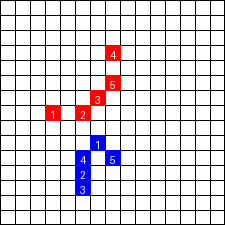

In [37]:
agent.load("shared_a2c_combat_best.pth", load_optimizers=False)

gif_path = play_and_make_gif(
    agent,
    gif_path="shared_a2c_combat.gif",
    max_ep_len=400,
    greedy=False,
    fps=10
)

display(Image(filename=gif_path))

In [13]:
import os
import numpy as np
import torch
import torch.nn.functional as F

class EnhancedA2CAgent(SharedA2CAgent):
    def __init__(self, config):
        super().__init__(config)
        self.value_coef = config.get("value_coef", 0.5)
        self.entropy_coef = config.get("entropy_coef", config.get("entropy", 0.01))
        self.max_grad_norm = config.get("max_grad_norm", 0.5)

    def _returns_advantages(self, rewards, dones, values, next_values):
        # rewards: [T, N]
        # dones:   [T, N]
        # values:  [T, N]
        # next_values: [N]
        T, N = rewards.shape
        returns = np.zeros((T, N), dtype=np.float32)

        future = next_values.astype(np.float32).copy()
        for t in reversed(range(T)):
            future = rewards[t] + self.gamma * future * (1.0 - dones[t].astype(np.float32))
            returns[t] = future

        advantages = returns - values
        return returns, advantages

    def optimize_model(self, observations, actions, returns, advantages):
        T, N, D = observations.shape

        obs_tensor = torch.tensor(observations, dtype=torch.float32).reshape(T * N, D)
        actions_tensor = torch.tensor(actions, dtype=torch.int64).reshape(T * N)
        returns_tensor = torch.tensor(returns, dtype=torch.float32).reshape(T * N)
        advantages_tensor = torch.tensor(advantages, dtype=torch.float32).reshape(T * N)

        if advantages_tensor.numel() > 1:
            advantages_tensor = (
                (advantages_tensor - advantages_tensor.mean())
                / (advantages_tensor.std() + 1e-8)
            )

        values_pred = self.value_network(obs_tensor).squeeze(-1)

        policy = self.actor_network(obs_tensor)
        dist = torch.distributions.Categorical(policy)
        log_probs = dist.log_prob(actions_tensor)
        entropy = dist.entropy().mean()

        actor_loss = -(log_probs * advantages_tensor.detach()).mean()
        critic_loss = F.mse_loss(values_pred, returns_tensor)

        total_loss = actor_loss + self.value_coef * critic_loss - self.entropy_coef * entropy

        self.actor_network_optimizer.zero_grad()
        self.value_network_optimizer.zero_grad()

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(self.actor_network.parameters(), self.max_grad_norm)
        torch.nn.utils.clip_grad_norm_(self.value_network.parameters(), self.max_grad_norm)

        self.actor_network_optimizer.step()
        self.value_network_optimizer.step()

        return {
            "total_loss": total_loss.item(),
            "actor_loss": actor_loss.item(),
            "critic_loss": critic_loss.item(),
            "entropy": entropy.item()
        }

    def training_batch(self, epochs, batch_size, save_path=None, save_every=None):
        out = self.env.reset()
        if isinstance(out, tuple):
            obs_n, _ = out
        else:
            obs_n = out

        obs_n = np.array(obs_n, dtype=np.float32)

        train_rewards = []
        eval_rewards = []
        best_eval_reward = -float("inf")

        for epoch in range(epochs):
            batch_obs = []
            batch_actions = []
            batch_rewards = []
            batch_dones = []
            batch_values = []

            rollout_reward = np.zeros(self.n_agents, dtype=np.float32)

            for _ in range(batch_size):
                obs_tensor = torch.tensor(obs_n, dtype=torch.float32)

                with torch.no_grad():
                    values = self.value_network(obs_tensor).squeeze(-1).cpu().numpy()
                    probs = self.actor_network(obs_tensor)
                    dist = torch.distributions.Categorical(probs)
                    actions = dist.sample().cpu().numpy()

                step_out = self.env.step(actions.tolist())

                if len(step_out) == 5:
                    next_obs_n, reward_n, terminated_n, truncated_n, _ = step_out
                    done_n = np.logical_or(terminated_n, truncated_n)
                else:
                    next_obs_n, reward_n, done_n, _ = step_out

                next_obs_n = np.array(next_obs_n, dtype=np.float32)
                reward_n = np.array(reward_n, dtype=np.float32)
                done_n = np.array(done_n, dtype=np.bool_)

                batch_obs.append(obs_n.copy())
                batch_actions.append(np.array(actions, dtype=np.int64))
                batch_rewards.append(reward_n)
                batch_dones.append(done_n)
                batch_values.append(np.array(values, dtype=np.float32))

                rollout_reward += reward_n
                obs_n = next_obs_n

                if all(done_n):
                    out = self.env.reset()
                    if isinstance(out, tuple):
                        obs_n, _ = out
                    else:
                        obs_n = out
                    obs_n = np.array(obs_n, dtype=np.float32)

            with torch.no_grad():
                next_values = self.value_network(
                    torch.tensor(obs_n, dtype=torch.float32)
                ).squeeze(-1).cpu().numpy()

            batch_obs = np.array(batch_obs, dtype=np.float32)         # [T, N, D]
            batch_actions = np.array(batch_actions, dtype=np.int64)   # [T, N]
            batch_rewards = np.array(batch_rewards, dtype=np.float32) # [T, N]
            batch_dones = np.array(batch_dones, dtype=np.bool_)       # [T, N]
            batch_values = np.array(batch_values, dtype=np.float32)   # [T, N]

            returns, advantages = self._returns_advantages(
                batch_rewards, batch_dones, batch_values, next_values
            )

            losses = self.optimize_model(
                batch_obs, batch_actions, returns, advantages
            )

            mean_train_reward = float(np.mean(rollout_reward))
            train_rewards.append(mean_train_reward)

            if (epoch + 1) % 50 == 0:
                eval_reward = self.evaluate(n_episodes=5)
                eval_rewards.append(eval_reward)

                print(
                    f"Epoch {epoch+1}/{epochs} | "
                    f"TrainReward={mean_train_reward:.3f} | "
                    f"EvalReward={eval_reward:.3f} | "
                    f"ActorLoss={losses['actor_loss']:.4f} | "
                    f"CriticLoss={losses['critic_loss']:.4f} | "
                    f"Entropy={losses['entropy']:.4f}"
                )

                if save_path is not None and eval_reward > best_eval_reward:
                    best_eval_reward = eval_reward
                    self.save(save_path)

            elif (epoch + 1) % 10 == 0:
                print(
                    f"Epoch {epoch+1}/{epochs} | "
                    f"TrainReward={mean_train_reward:.3f} | "
                    f"ActorLoss={losses['actor_loss']:.4f} | "
                    f"CriticLoss={losses['critic_loss']:.4f} | "
                    f"Entropy={losses['entropy']:.4f}"
                )

            if save_every is not None and save_path is not None:
                if (epoch + 1) % save_every == 0:
                    base, ext = os.path.splitext(save_path)
                    ckpt_path = f"{base}_ep{epoch+1}{ext}"
                    self.save(ckpt_path)

        return train_rewards, eval_rewards

    def evaluate(self, n_episodes=5):
        episode_rewards = []

        for _ in range(n_episodes):
            out = self.env.reset()
            if isinstance(out, tuple):
                obs_n, _ = out
            else:
                obs_n = out

            obs_n = np.array(obs_n, dtype=np.float32)
            done_n = np.array([False] * self.n_agents)
            total_reward = np.zeros(self.n_agents, dtype=np.float32)

            while not all(done_n):
                obs_tensor = torch.tensor(obs_n, dtype=torch.float32)

                with torch.no_grad():
                    probs = self.actor_network(obs_tensor)
                    actions = torch.argmax(probs, dim=1).cpu().numpy()

                step_out = self.env.step(actions.tolist())

                if len(step_out) == 5:
                    next_obs_n, reward_n, terminated_n, truncated_n, _ = step_out
                    done_n = np.logical_or(terminated_n, truncated_n)
                else:
                    next_obs_n, reward_n, done_n, _ = step_out

                total_reward += np.array(reward_n, dtype=np.float32)
                obs_n = np.array(next_obs_n, dtype=np.float32)

            episode_rewards.append(float(np.mean(total_reward)))

        return float(np.mean(episode_rewards))

In [15]:
config = {
    "env_id": "ma_gym:Combat-v0",
    "seed": 42,
    "gamma": 0.99,
    "hidden_size": 128,
    "actor_network": {"learning_rate": 3e-4},
    "value_network": {"learning_rate": 1e-3},

    "value_coef": 0.5,
    "entropy": 0.01,
    "entropy_coef": 0.01,
    "max_grad_norm": 0.5,
}

In [16]:
agent = EnhancedA2CAgent(config)

train_rewards, eval_rewards = agent.training_batch(
    epochs=1200,
    batch_size=128,
    save_path="enhanced_shared_a2c_combat_best.pth",
    save_every=300
)

Epoch 10/1200 | TrainReward=-14.600 | ActorLoss=0.0065 | CriticLoss=0.2737 | Entropy=2.2978
Epoch 20/1200 | TrainReward=-7.800 | ActorLoss=-0.0128 | CriticLoss=0.2342 | Entropy=2.2928
Epoch 30/1200 | TrainReward=-12.400 | ActorLoss=-0.0070 | CriticLoss=0.3252 | Entropy=2.2689
Epoch 40/1200 | TrainReward=-7.200 | ActorLoss=-0.0019 | CriticLoss=0.2491 | Entropy=2.2416


You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


Epoch 50/1200 | TrainReward=-0.400 | EvalReward=-2.640 | ActorLoss=-0.0128 | CriticLoss=2.1793 | Entropy=2.2168
Epoch 60/1200 | TrainReward=-7.600 | ActorLoss=0.0010 | CriticLoss=0.2865 | Entropy=2.2075
Epoch 70/1200 | TrainReward=-12.000 | ActorLoss=0.0179 | CriticLoss=0.2629 | Entropy=2.1973
Epoch 80/1200 | TrainReward=-8.000 | ActorLoss=-0.0300 | CriticLoss=0.2055 | Entropy=2.1873
Epoch 90/1200 | TrainReward=-3.800 | ActorLoss=-0.0390 | CriticLoss=0.9033 | Entropy=2.1641


You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


Epoch 100/1200 | TrainReward=-15.600 | EvalReward=-2.440 | ActorLoss=-0.0731 | CriticLoss=0.3852 | Entropy=2.1287
Epoch 110/1200 | TrainReward=-5.000 | ActorLoss=-0.0120 | CriticLoss=0.3863 | Entropy=2.0720
Epoch 120/1200 | TrainReward=-2.400 | ActorLoss=-0.0746 | CriticLoss=0.8055 | Entropy=2.0900
Epoch 130/1200 | TrainReward=-8.200 | ActorLoss=-0.0591 | CriticLoss=0.2358 | Entropy=2.0182
Epoch 140/1200 | TrainReward=-13.400 | ActorLoss=-0.0224 | CriticLoss=0.2524 | Entropy=2.1038


...

Epoch 1050/1200 | TrainReward=-9.000 | EvalReward=-2.000 | ActorLoss=0.0036 | CriticLoss=0.2967 | Entropy=1.7856
Epoch 1060/1200 | TrainReward=-11.600 | ActorLoss=-0.0463 | CriticLoss=0.4158 | Entropy=1.9434
Epoch 1070/1200 | TrainReward=-10.200 | ActorLoss=0.0662 | CriticLoss=0.2659 | Entropy=1.9484
Epoch 1080/1200 | TrainReward=-9.400 | ActorLoss=-0.0165 | CriticLoss=0.3131 | Entropy=1.8391
Epoch 1090/1200 | TrainReward=-8.200 | ActorLoss=-0.0401 | CriticLoss=0.3758 | Entropy=1.8390


You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


Epoch 1100/1200 | TrainReward=-7.600 | EvalReward=-1.960 | ActorLoss=0.0264 | CriticLoss=0.5158 | Entropy=1.8467
Epoch 1110/1200 | TrainReward=-5.600 | ActorLoss=-0.0215 | CriticLoss=0.2231 | Entropy=1.8966
Epoch 1120/1200 | TrainReward=-10.600 | ActorLoss=0.0221 | CriticLoss=0.4004 | Entropy=1.8818
Epoch 1130/1200 | TrainReward=-4.400 | ActorLoss=0.0171 | CriticLoss=0.2977 | Entropy=1.7272
Epoch 1140/1200 | TrainReward=-7.000 | ActorLoss=-0.0186 | CriticLoss=0.2306 | Entropy=2.0065


You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.


Epoch 1150/1200 | TrainReward=-6.000 | EvalReward=-1.960 | ActorLoss=0.0186 | CriticLoss=0.2291 | Entropy=2.0717
Epoch 1160/1200 | TrainReward=-1.800 | ActorLoss=-0.0205 | CriticLoss=1.2965 | Entropy=1.7677
Epoch 1170/1200 | TrainReward=-6.600 | ActorLoss=-0.0205 | CriticLoss=0.2324 | Entropy=1.9100
Epoch 1180/1200 | TrainReward=-7.800 | ActorLoss=0.0821 | CriticLoss=0.2168 | Entropy=1.9840
Epoch 1190/1200 | TrainReward=-8.800 | ActorLoss=-0.0185 | CriticLoss=0.3982 | Entropy=1.7504
Epoch 1200/1200 | TrainReward=-2.400 | EvalReward=-2.240 | ActorLoss=-0.0605 | CriticLoss=0.3100 | Entropy=1.5684


In [1]:
agent.load("enhanced_shared_a2c_combat_best.pth", load_optimizers=False)

gif_path = play_and_make_gif(
    agent,
    gif_path="shared_a2c_combat.gif",
    max_ep_len=400,
    greedy=False,
    fps=10
)

display(Image(filename=gif_path))

NameError: name 'agent' is not defined